# Smart Charging using Reinforcement Learning
Task description is summarized as follows:
- EV taxi is charged at home and an RL agent should manage the charging to complete the working day
- EV arrives at <b>2 p.m. at leaves at 4 p.m. each day</b>
- Adjustments to charging power can be made <b>every 15 minutes</b>
- Charging power is between 0 kW and 22 kW
- Energy demand follows a normal distribution (𝜇= 30 kWh, 𝜎= 5 kW)
- Energy demand for after 4 pm is generated when leaving
- Running out of energy is the worst case -> high penalty
- Goal is to minimize recharging cost
- Vehicle's battery has a capacity that cannot be exceeded
- Recharging cost follows an exponential function of the power (i.e., charging cost (t, p) = ∑ 𝛼!𝑒" !∈$ ) 𝛼! is the time coefficient and p is the charging rate 
- Create the environment (<b>simple discrete event simulation</b>) that returns agent's decisions and returns reward
- Define markov decision process, inclduing states, actions, and reward function
- Solve MDP using RL algorithm to find optimal charging policies
- Limited charging options such as zero, low, medium, high


Generally this tasks is splitted into three steps:
1. Simulation of the environment
2. Define Markov Decision Process
3. Let agents learn

As not all information are defined by the task, we work with assumptions.

> Assumption: We use a 60 kWh battery capacity which is in the middle of some german car manufacturer ([OPEL](https://www.opel.de/e-mobilitaet/elektro-modelle.html), [BMW](https://www.bmw.de/de/elektroauto.html#modelle))

> Assumption: There is no description about how much energy is left in the battery when the car arrives. Therefore we randomly select one based on the normal distribution, assuming that the taxi does a trip before 2 pm of the same scale.

> Assumption: The driver will not return with a completely empty battery, hence the minimum sampled will be 0.5 kWh.

> Assumption: As the vehicle is charged at home, we assume that the energy therefore alpha is set to 1

> Assumption: To avoid that the prices skyrock (e^22), we normalize it through the maximal power

> Assumption: Available battery capacity and charging speed decide about how much is actually charged. This estimated value is used for cost calculation.

In [38]:
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

import simpy                                       
import gymnasium as gym                             
from gymnasium import spaces
from gymnasium.wrappers import TransformReward
import torch                                        
from stable_baselines3 import DQN                   
from stable_baselines3.common.monitor import Monitor
%matplotlib inline

import random
import math
from collections import deque
 
import numpy as np
import simpy
import torch
import torch.nn as nn
import torch.optim as optim
 
RANDOM_SEED = 42
BATTERY_CAPACITY = 60.0               # kWh - battery size

# 1. Simulation of the environment
Parameters and relevant design elements:
- Entity: Taxi with battery at the home charger
- Events:
    - Start event: Arrival at 2 pm
    - In-between events: Eight decision epochs - from start to end every 15min
    - End event:Departure at 4pm (stochastic demand is realised)
- Activity: Charging for 15 minute time slots at the given power
- Resource: Home charger and battery that cannot be exceeded


## 1.1 Stochastic distributions
### 1.1.1 Energy Demand
<i>"Energy demand follows a normal distribution (𝜇= 30 kWh, 𝜎= 5 kW)"</i>

> Additional assumption was made that the driver will not return with a completely empty battery, hence the minimum sampled will be 0.5 kWh.

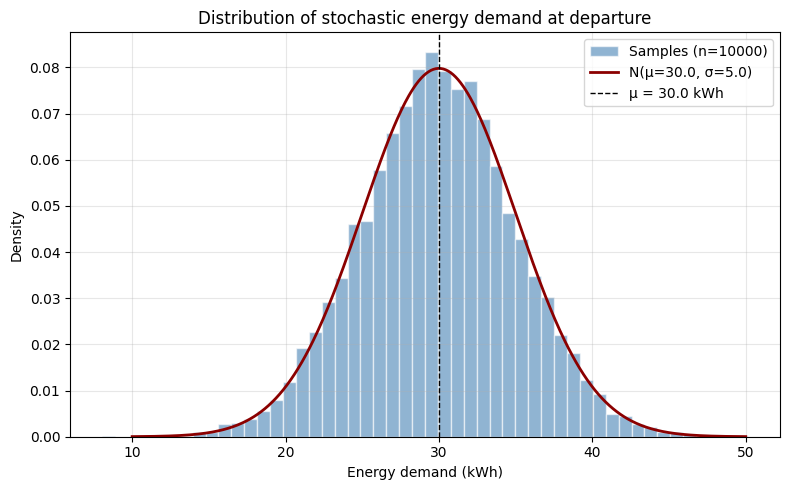

In [39]:
demand_rng = np.random.default_rng(RANDOM_SEED)

def sample_energy_demand(mu=30.0, sigma=5.0, generator=demand_rng, max_demand=BATTERY_CAPACITY):
    """
    Draw energy demand from a normal distribution, clipped to
    [0.5, max_demand] — can't be negative, and can't exceed
    the battery's maximum capacity (BATTERY_CAPACITY kWh).
    """
    demand = generator.normal(mu, sigma)
    return np.clip(demand, 0.5, max_demand)


# Plot
n_samples = 10000
mu = 30.0
sigma = 5.0

# generate samples
samples = np.array([sample_energy_demand(mu, sigma) for _ in range(n_samples)])

# plot
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(samples, bins=50, density=True, alpha=0.6, color="steelblue", edgecolor="white", label=f"Samples (n={n_samples})")


x = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 500)
pdf = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)
ax.plot(x, pdf, color="darkred", lw=2, label=f"N(μ={mu}, σ={sigma})")

ax.axvline(mu, color="black", linestyle="--", lw=1, label=f"μ = {mu} kWh")
ax.set_xlabel("Energy demand (kWh)")
ax.set_ylabel("Density")
ax.set_title("Distribution of stochastic energy demand at departure")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 1.1.2 Recharging costs
"Recharging cost follows an exponential function of the power (i.e., charging cost (t, p) = ∑ 𝛼!𝑒" !∈$ ) 𝛼! is the time coefficient and p is the charging rate"

> Assumption: As the vehicle is charged at home, we assume that the energy therefore alpha is set to 1

> Assumption: To avoid that the prices skyrock (e^22), we normalize it through the maximal power

> Assumption: Available battery capacity and charging speed decide about how much is actually charged. This estimated value is used for cost calculation.

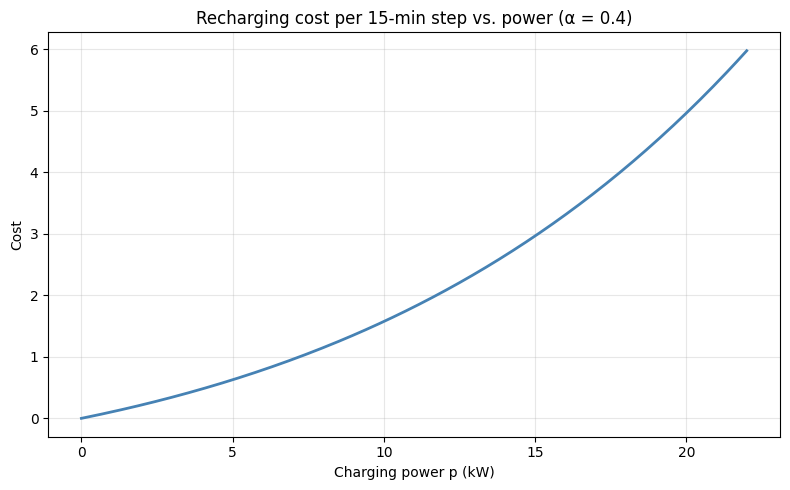

In [40]:
ALPHA = 0.4    # price coefficient alpha_t = home electricity tariff, €/kWh, constant over time
P_MAX = 22.0   # kW, highest charging rate
DT = 0.25      # hours per 15-min decision step


def charged_energy(power, soc, capacity=BATTERY_CAPACITY, dt=DT):
    """
    Calculates the energy that can be charged in a single step,
    given the charging power and the available space in the battery (capacity - soc). 
    """
    space = np.maximum(0.0, capacity - soc)
    return np.minimum(power * dt, space)


def charging_cost(power, energy, alpha=ALPHA, p_max=P_MAX):
    """
    Calculates the cost of charging a given amount of energy at a given power level,
    using a cost function that increases exponentially with power.
    """
    return alpha * energy * np.exp(power / p_max)



powers = np.linspace(0, P_MAX, 200)
costs = charging_cost(powers, charged_energy(powers, soc=0.0))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(powers, costs, color="steelblue", lw=2)
ax.set_xlabel("Charging power p (kW)")
ax.set_ylabel("Cost")
ax.set_title(f"Recharging cost per 15-min step vs. power (α = {ALPHA})")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [41]:
STEP_MINUTES = 15                     # agent re-decides charging power every 15 min
SESSION_MINUTES = 120                 # car is home from 2:00pm to 4:00pm
N_STEPS = SESSION_MINUTES // STEP_MINUTES     # 8 decision points per day

ACTION_POWERS = [0.0, 4.4, 8.8, 13.2, 17.6, 22.0]
ACTION_LABELS = ["zero", "very low", "low", "medium", "high", "very high"]

N_ACTIONS = len(ACTION_POWERS)

PENALTY_PER_KWH = 500.0               # penalty for every KWh of unmet demand

As some information are not explicitly given by the task description we work with additional assumptions.
> Assumption: There is no description about how much energy is left in the battery when the car arrives. Therefore we randomly select one based on the normal distribution, assuming that the taxi does a trip before 2 pm of the same scale.

# 2. Markov Decision Process

The environment is implemented as a `gymnasium.Env` so that it can be handed directly to a Stable-Baselines3 agent.

**State** $s_t = (t,\ soc_t)$, normalised to $[0,1]$ as $(t/8,\ soc/60)$.

The realised demand is *not* part of the state but is calculated at departure. So the agent is limited to knowing that the time step and the demand.

**Action** $a_t \in \{0,\dots,5\}$. The agent has the possible actions of charging at different speeds: 0 / 4.4 / 8.8 / 13.2 / 17.6 / 22.0 kW 

**Transition** $soc_{t+1} = soc_t + \min(p_{a}\cdot \Delta t,\ 60 - soc_t)$, with $\Delta t = 0.25$ h. Battery capacity is enforced inside `charged_energy()`, so the state can not be overcharged.

**Reward**
Reward consists of negative costs and the penalty which is set for `500 * kWh_missed`

$$r_t = -\alpha \cdot e_t \cdot e^{p_t/p_{max}} \qquad\text{for } t < 8$$

$$r_8 = -\alpha \cdot e_8 \cdot e^{p_8/p_{max}} - 500 \cdot \max(0,\ D - soc_8), \qquad D \sim \mathcal{N}(30, 5)$$

**Horizon** 8 steps, finite and fixed, so every episode terminates at 4 pm (`terminated=True`); `truncated` is always `False` since there is no external time limit.

In [42]:
class ChargingEnv(gym.Env):
    """
    Gymnasium environment for the smart-charging MDP.

    The agent picks a charging power every 15 minutes; the environment returns
    the resulting state, reward and termination flag.

    Each step follows three stages:
      1. the agent selects a charging power,
      2. `charged_energy()` estimates how much the battery absorbs in the
         coming 15 minutes (this is where the step length dt enters),
      3. `charging_cost()` prices that energy at the flat tariff ALPHA.

    At departure (t = N_STEPS) the stochastic demand is realised and any
    unmet energy is penalised at PENALTY_PER_KWH.
    """

    metadata = {"render_modes": []}

    def __init__(self, verbose=False):
        super().__init__()
        self.action_space = spaces.Discrete(N_ACTIONS)
        self.observation_space = spaces.Box(low=0.0, high=1.0, shape=(2,), dtype=np.float32)
        self.verbose = verbose
        self.rng = np.random.default_rng(RANDOM_SEED)   # per-instance random stream
        self.time = 0
        self.state_of_charge = 0.0

    def _obs(self):
        """Scale (t, soc) to [0, 1] for the neural network."""
        return np.array(
            [self.time / N_STEPS, self.state_of_charge / BATTERY_CAPACITY],
            dtype=np.float32,
        )

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        if seed is not None:
            self.rng = np.random.default_rng(seed)
        self.time = 0

        self.state_of_charge = float(sample_energy_demand(mu=20, sigma=5, generator=self.rng))
        return self._obs(), {}

    def step(self, action):
        # Select charging power
        power = ACTION_POWERS[int(action)]

        # Calculate possible energy charged in this step and price
        energy = float(charged_energy(power, self.state_of_charge))
        cost = float(charging_cost(power, energy))

        self.state_of_charge += energy  # no battery overflow, see charged_energy()
        self.time += 1

        reward = -cost
        terminated = self.time >= N_STEPS   # episode ends at departure (4 pm)
        truncated = False                   # no external time limit
        info = {
            "power": power,
            "energy": energy,
            "cost": cost,
            "battery_full": self.state_of_charge >= BATTERY_CAPACITY,
            "demand": None,
            "shortfall": None,
            "penalty": 0.0,
        }

        # Departure: realise stochastic demand and penalise unmet energy
        if terminated:
            demand = float(sample_energy_demand(mu=30, sigma=5, generator=self.rng))
            shortfall = max(0.0, demand - self.state_of_charge)
            penalty = PENALTY_PER_KWH * shortfall
            reward -= penalty
            info.update(demand=demand, shortfall=shortfall, penalty=penalty)

        if self.verbose:
            print(f"Step {self.time}: Action={ACTION_LABELS[int(action)]}, "
                  f"Power={power:.1f} kW, Energy={energy:.2f} kWh, Cost={cost:.2f} €")

        return self._obs(), reward, terminated, truncated, info

# 3. Baseline: evenly distributed charging

To have a baseline, we set the simple rule to charge as much as possible evenly distributed over the 8 time slots.
So on arrival we calculate the energy missing to a full battery and divide it by 8. That gives the kWh per slot; dividing by the slot length $\Delta t = 0.25$ h turns it into the charging power the rule holds for the whole session:

$$p = \frac{60 - soc_0}{8 \cdot \Delta t}$$

If that value is above 22 kW, the rule simply charges as much as possible.

Since the available powers are discrete, the required power is rounded up to the next level, so the baseline slightly overshoots the target rather than undershooting it.

The rule uses only the arrival SoC and never re-plans — it is deliberately naive. It should almost never run out of energy, but it pays for a full battery every day while the taxi only needs ~30 kWh, so this is the cost the learned policy has to beat.

In [43]:
def even_spread_action(soc_arrival, capacity=BATTERY_CAPACITY):
    """
    Baseline rule, decided once on arrival at 2 pm.

    The energy missing to a full battery is spread evenly over the 8 slots.
    Dividing by N_STEPS gives the kWh per slot, dividing by DT turns that into
    the kW the charger has to hold. If more than the strongest level would be
    needed, charge as much as possible instead.
    """
    missing_energy = max(0.0, capacity - soc_arrival)   # kWh
    energy_per_step = missing_energy / N_STEPS          # kWh per 15-min slot
    required_power = energy_per_step / DT               # kW held constant for 2 h

    for idx, power in enumerate(ACTION_POWERS):
        if power >= required_power - 1e-9:
            return idx
    return N_ACTIONS - 1                                # > 22 kW needed -> charge flat out


def run_baseline(n_episodes=2000, seed=RANDOM_SEED):
    """Roll out the baseline policy on ChargingEnv and collect per-episode results."""
    env = ChargingEnv()
    records = []

    for episode in range(n_episodes):
        env.reset(seed=seed + episode)
        soc_arrival = env.state_of_charge

        action = even_spread_action(soc_arrival)   # decided once at 2 pm, then held
        cost = 0.0
        while True:
            _, _, terminated, _, info = env.step(action)
            cost += info["cost"]
            if terminated:
                break

        records.append({
            "arrival_soc": soc_arrival,
            "power": ACTION_POWERS[action],
            "final_soc": env.state_of_charge,
            "demand": info["demand"],
            "cost": cost,
            "shortfall": info["shortfall"],
            "penalty": info["penalty"],
            "reward": -(cost + info["penalty"]),
        })

    return pd.DataFrame(records)


baseline = run_baseline()

print(f"Baseline: evenly spread charging to a full battery, {len(baseline)} episodes\n")
print(f"  mean charging cost   {baseline['cost'].mean():8.2f} EUR")
print(f"  mean penalty         {baseline['penalty'].mean():8.2f} EUR")
print(f"  mean total reward    {baseline['reward'].mean():8.2f}")
print(f"  episodes w/ shortfall{baseline['shortfall'].gt(0).mean():8.2%}")
print(f"  mean shortfall       {baseline['shortfall'].mean():8.3f} kWh")
print(f"  mean arrival SoC     {baseline['arrival_soc'].mean():8.2f} kWh")
print(f"  mean final SoC       {baseline['final_soc'].mean():8.2f} kWh")

Baseline: evenly spread charging to a full battery, 2000 episodes

  mean charging cost      41.61 EUR
  mean penalty             0.00 EUR
  mean total reward      -41.61
  episodes w/ shortfall   0.00%
  mean shortfall          0.000 kWh
  mean arrival SoC        20.17 kWh
  mean final SoC          59.47 kWh
